In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
 
import math
import numpy as np
import random

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.transforms as transforms
from torchvision.models import efficientnet_b0
from PIL import Image
from tqdm.notebook import tqdm
from syn2real_dataset import Syn2RealDataset
from string_to_xml_to_vec import string2vec, vec2string, vec2xml, pretty_print_xml
import numpy as np
import math
import os

# Add ../ as a directory to import from
import sys
sys.path.append('../')

from config import Config

In [2]:
from torch.utils.data import DataLoader
from plant_dataset import PlantDataset 

image_size = 224

from plant_tokenizer import PAD_token

transform = transforms.Compose([
                        transforms.ToTensor(),
                        transforms.Normalize(mean=[0.5, 0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5, 0.5])
        ])

import pickle
# Check if the .plk file exists
dataset_dir = "../data/generated_dataset_Sep22_black"
saved_train_dataset_name = os.path.join(dataset_dir,"train_dataset.pkl")
saved_val_dataset_name = os.path.join(dataset_dir,"val_dataset.pkl")
if os.path.exists(saved_train_dataset_name) and False:
    if os.path.exists(saved_train_dataset_name):
        print("Loading plant dataset from .pkl file")
        with open(saved_train_dataset_name, "rb") as f:
            train_dataset = pickle.load(f)
        with open(saved_val_dataset_name, "rb") as f:
            val_dataset = pickle.load(f)
else:
    preload = False
    process_leaf = True
    train_dataset = PlantDataset(dataset_dir, plot=["000", "001", "002",], 
                                 stages=["003"],
                                 transform=transform, use_depth=True, preload=preload,
                                 process_leaf=process_leaf,
                                 image_size=image_size) 
    #train_dataset = PlantDataset("../_data/Syn2Real_cowpea/Syn2Real_cowpea", plot=["000"], transform=transform)
    val_dataset = PlantDataset(dataset_dir, plot=["003"], transform=transform, use_depth=True, preload=preload,
                               process_leaf=process_leaf,
                               image_size=image_size)

    if preload:
        with open(saved_train_dataset_name, "wb") as f:
            pickle.dump(train_dataset, f)
        with open(saved_val_dataset_name, "wb") as f:
            pickle.dump(val_dataset, f)

Total 1159 images and plant strings loaded
Total 1585 images and plant strings loaded


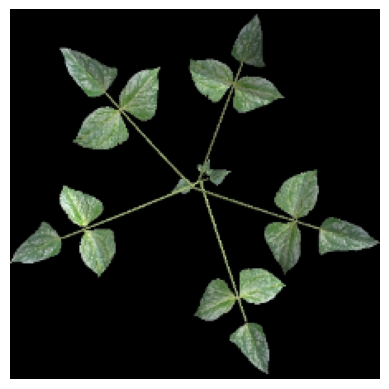

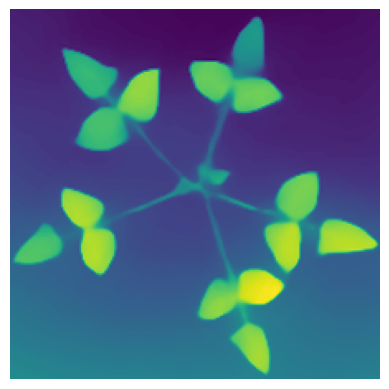

In [3]:
import cv2
img, target, depth = train_dataset[0]


rgb = img[:3]
# Normalize the RGB image to 0-255
rgb = cv2.normalize(rgb.permute(1,2,0).numpy(), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)

depth = img[3:]



import matplotlib.pyplot as plt
plt.imshow(rgb)
# Axes are not needed
plt.axis('off')
plt.show()
plt.imshow(depth[0])
plt.axis('off')
plt.show()


In [4]:
from models.plightning import SimpleRegressionTest
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleRegressionTest.load_from_checkpoint("../log/20241002_SimpleRegressionTest_RPY/version_0/checkpoints/last.ckpt")
model = model.to(device)
model.eval()
# model.freeze()

SimpleRegressionTest(
  (feature_extractor): ViT_FeatureExtractor(
    (model): ViTModel(
      (embeddings): ViTEmbeddings(
        (patch_embeddings): ViTPatchEmbeddings(
          (projection): Conv2d(4, 768, kernel_size=(16, 16), stride=(16, 16))
        )
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (encoder): ViTEncoder(
        (layer): ModuleList(
          (0-11): 12 x ViTLayer(
            (attention): ViTSdpaAttention(
              (attention): ViTSdpaSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.0, inplace=False)
              )
              (output): ViTSelfOutput(
                (dense): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.0, inplace=False)
              )
    

In [5]:
from torch.utils.data import DataLoader
from tqdm import tqdm

# Define batch size
batch_size = 32

# Create DataLoader
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# Initialize lists to store predictions and targets
first_vec_pred = []
first_vec_target = []

# Iterate over the DataLoader
for batch in tqdm(train_dataloader):
    imgs, targets, _ = batch
    imgs = imgs.to(device)
    
    with torch.no_grad():
        preds = model(imgs)
    
    # Append predictions and targets
    first_vec_pred.extend(preds.cpu().numpy())
    first_vec_target.extend(targets[:, 1, 1:5].cpu().numpy())

# Convert lists to numpy arrays if needed
first_vec_pred = np.array(first_vec_pred)
first_vec_target = np.array(first_vec_target)

first_vec_target_euler = first_vec_target * 180 / math.pi
first_vec_pred_euler = first_vec_pred * 180 / math.pi



# Plot the predictions and targets
import matplotlib.pyplot as plt
import numpy as np

# Create a 3x1 subplot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Define the range for the 1:1 line
min_val = min(np.min(first_vec_target_euler[:, 0]), np.min(first_vec_pred_euler[:, 0]))
max_val = max(np.max(first_vec_target_euler[:, 0]), np.max(first_vec_pred_euler[:, 0]))

# First subplot: pitch
axes[0].scatter(first_vec_target_euler[:, 0], first_vec_pred_euler[:, 0], label="pitch")
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', label="1:1 line")
axes[0].legend()
axes[0].set_title("Pitch (deg)")
axes[0].set_ylabel("Predicted")
axes[0].set_xlabel("Target")

# Second subplot: yaw
min_val = min(np.min(first_vec_target_euler[:, 1]), np.min(first_vec_pred_euler[:, 1]))
max_val = max(np.max(first_vec_target_euler[:, 1]), np.max(first_vec_pred_euler[:, 1]))
axes[1].scatter(first_vec_target_euler[:, 1], first_vec_pred_euler[:, 1], label="yaw")
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', label="1:1 line")
axes[1].legend()
axes[1].set_title("Yaw (deg)")
axes[1].set_ylabel("Predicted")
axes[1].set_xlabel("Target")

# Third subplot: roll
min_val = min(np.min(first_vec_target_euler[:, 2]), np.min(first_vec_pred_euler[:, 2]))
max_val = max(np.max(first_vec_target_euler[:, 2]), np.max(first_vec_pred_euler[:, 2]))
axes[2].scatter(first_vec_target_euler[:, 2], first_vec_pred_euler[:, 2], label="roll")
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--', label="1:1 line")
axes[2].legend()
axes[2].set_title("Roll (deg)")
axes[2].set_ylabel("Predicted")
axes[2].set_xlabel("Target")

# Adjust layout

# Add a figure title
fig.suptitle("Predictions vs Targets (Training)", fontsize=16)


plt.tight_layout()
plt.show()

100%|██████████| 37/37 [01:19<00:00,  2.15s/it]


In [17]:
from torch.utils.data import DataLoader
from tqdm import tqdm

# Define batch size
batch_size = 32

test_dataset = PlantDataset(dataset_dir, plot=["004"], 
                            stages=["003"],
                            transform=transform, use_depth=True, preload=preload,
                               process_leaf=process_leaf,
                               image_size=image_size)
# Create DataLoader
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# Initialize lists to store predictions and targets
first_vec_pred = []
first_vec_target = []

# Iterate over the DataLoader
for batch in tqdm(test_dataloader):
    imgs, targets, _ = batch
    imgs = imgs.to(device)
    
    with torch.no_grad():
        preds = model(imgs)
    
    # Append predictions and targets
    first_vec_pred.extend(preds.cpu().numpy())
    first_vec_target.extend(targets[:, 1, 1:5].cpu().numpy())

# Convert lists to numpy arrays if needed
first_vec_pred = np.array(first_vec_pred)
first_vec_target = np.array(first_vec_target)

first_vec_target_euler = first_vec_target * 180 / math.pi
first_vec_pred_euler = first_vec_pred * 180 / math.pi




Total 368 images and plant strings loaded


  0%|          | 0/12 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:35<00:00,  2.99s/it]


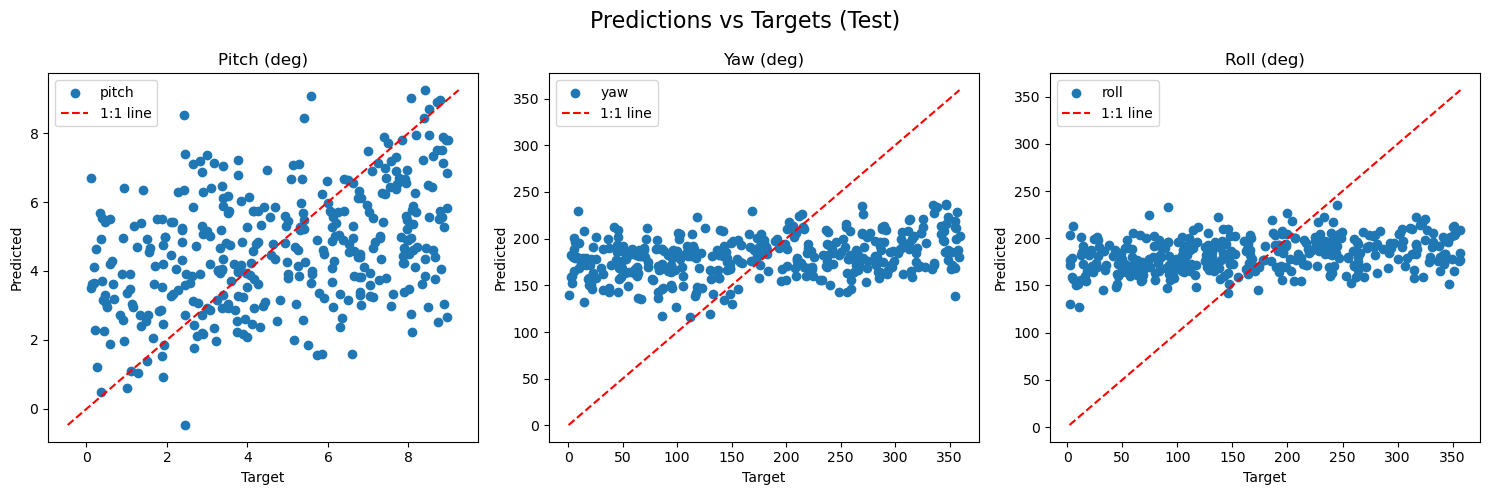

In [18]:

# Plot the predictions and targets
import matplotlib.pyplot as plt
import numpy as np

# Create a 3x1 subplot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Define the range for the 1:1 line
min_val = min(np.min(first_vec_target_euler[:, 0]), np.min(first_vec_pred_euler[:, 0]))
max_val = max(np.max(first_vec_target_euler[:, 0]), np.max(first_vec_pred_euler[:, 0]))

# First subplot: pitch
axes[0].scatter(first_vec_target_euler[:, 0], first_vec_pred_euler[:, 0], label="pitch")
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', label="1:1 line")
axes[0].legend()
axes[0].set_title("Pitch (deg)")
axes[0].set_ylabel("Predicted")
axes[0].set_xlabel("Target")

# Second subplot: yaw
min_val = min(np.min(first_vec_target_euler[:, 1]), np.min(first_vec_pred_euler[:, 1]))
max_val = max(np.max(first_vec_target_euler[:, 1]), np.max(first_vec_pred_euler[:, 1]))
axes[1].scatter(first_vec_target_euler[:, 1], first_vec_pred_euler[:, 1], label="yaw")
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', label="1:1 line")
axes[1].legend()
axes[1].set_title("Yaw (deg)")
axes[1].set_ylabel("Predicted")
axes[1].set_xlabel("Target")

# Third subplot: roll
min_val = min(np.min(first_vec_target_euler[:, 2]), np.min(first_vec_pred_euler[:, 2]))
max_val = max(np.max(first_vec_target_euler[:, 2]), np.max(first_vec_pred_euler[:, 2]))
axes[2].scatter(first_vec_target_euler[:, 2], first_vec_pred_euler[:, 2], label="roll")
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--', label="1:1 line")
axes[2].legend()
axes[2].set_title("Roll (deg)")
axes[2].set_ylabel("Predicted")
axes[2].set_xlabel("Target")

# Adjust layout

# Add a figure title
fig.suptitle("Predictions vs Targets (Test)", fontsize=16)


plt.tight_layout()
plt.show()

In [44]:
# Convert quaternion to euler angles

# def quaternion_to_euler_angle(w, x, y, z):
#     ysqr = y * y

#     t0 = +2.0 * (w * x + y * z)
#     t1 = +1.0 - 2.0 * (x * x + ysqr)
#     X = math.degrees(math.atan2(t0, t1))

#     t2 = +2.0 * (w * y - z * x)
#     t2 = +1.0 if t2 > +1.0 else t2
#     t2 = -1.0 if t2 < -1.0 else t2
#     Y = math.degrees(math.asin(t2))

#     t3 = +2.0 * (w * z + x * y)
#     t4 = +1.0 - 2.0 * (ysqr + z * z)
#     Z = math.degrees(math.atan2(t3, t4))

#     return X, Y, Z

def quaternion_to_euler_angle(w, x, y, z):
    q = np.array([w, x, y, z])
    # Normalize quaternion
    q = q / np.linalg.norm(q)
    
    # Compute roll, pitch, yaw
    sinr_cosp = 2 * (q[0] * q[1] + q[2] * q[3])
    cosr_cosp = 1 - 2 * (q[1] * q[1] + q[2] * q[2])
    roll = math.atan2(sinr_cosp, cosr_cosp)

    sinp = 2 * (q[0] * q[2] - q[3] * q[1])
    if abs(sinp) >= 1:
        pitch = math.copysign(math.pi / 2, sinp)
    else:
        pitch = math.asin(sinp)

    siny_cosp = 2 * (q[0] * q[3] + q[1] * q[2])
    cosy_cosp = 1 - 2 * (q[2] * q[2] + q[3] * q[3])
    yaw = math.atan2(siny_cosp, cosy_cosp)

    # Convert radians to degrees
    roll = math.degrees(roll)
    pitch = math.degrees(pitch)
    yaw = math.degrees(yaw)

    return roll, pitch, yaw

# Convert quaternion to euler angles
first_euler_pred = np.array([quaternion_to_euler_angle(*q) for q in first_vec_pred])
first_euler_target = np.array([quaternion_to_euler_angle(*q) for q in first_vec_target])

# Calculate the mean absolute error
mae = np.mean(np.abs(first_euler_pred - first_euler_target), axis=0)
print("Mean Absolute Error (MAE) in degrees:", mae)

# Calculate the root mean squared error
rmse = np.sqrt(np.mean((first_euler_pred - first_euler_target) ** 2, axis=0))
print("Root Mean Squared Error (RMSE) in degrees:", rmse)



Mean Absolute Error (MAE) in degrees: [1.32915967 0.76339275 1.6362946 ]
Root Mean Squared Error (RMSE) in degrees: [14.94497366  1.00919482 18.2944152 ]


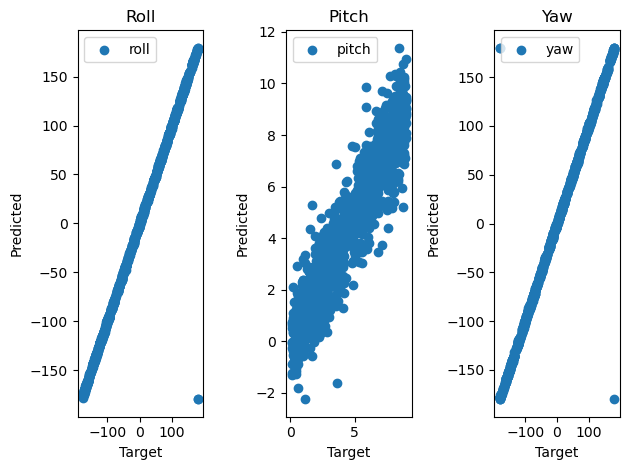

MSE: 6.803332816418431e-05
MAE: 0.006350181274773134


In [60]:
# Plot the predictions and targets
import matplotlib.pyplot as plt

# Create a 3x1 subplot
fig, axes = plt.subplots(1, 3)

# First subplot: roll
axes[0].scatter(first_euler_target[:, 0], first_euler_pred[:, 0], label="roll")
axes[0].legend()
axes[0].set_title("Roll")
axes[0].set_ylabel("Predicted")
axes[0].set_xlabel("Target")

# Second subplot: pitch
axes[1].scatter(first_euler_target[:, 1], first_euler_pred[:, 1], label="pitch")
axes[1].legend()
axes[1].set_title("Pitch")
axes[1].set_ylabel("Predicted")
axes[1].set_xlabel("Target")

# Third subplot: yaw
axes[2].scatter(first_euler_target[:, 2], first_euler_pred[:, 2], label="yaw")
axes[2].legend()
axes[2].set_title("Yaw")
axes[2].set_ylabel("Predicted")
axes[2].set_xlabel("Target")

# Adjust layout
plt.tight_layout()
plt.show()


# Calculate the mean squared error
mse = np.mean((first_vec_pred - first_vec_target) ** 2)
print(f"MSE: {mse}")

# Calculate the mean absolute error
mae = np.mean(np.abs(first_vec_pred - first_vec_target))
print(f"MAE: {mae}")

In [56]:
from torch.utils.data import DataLoader
from tqdm import tqdm

# Define batch size
batch_size = 32

# Create DataLoader
val_dataset = PlantDataset(dataset_dir, plot=["003"], 
                           stages=["003"],
                           transform=transform, use_depth=True, preload=preload,
                            process_leaf=process_leaf,
                            image_size=image_size)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# Initialize lists to store predictions and targets
val_first_vec_pred = []
val_first_vec_target = []

# Iterate over the DataLoader
for batch in tqdm(val_dataloader):
    imgs, targets, _ = batch
    imgs = imgs.to(device)
    
    with torch.no_grad():
        preds = model(imgs)
    
    # Append predictions and targets
    val_first_vec_pred.extend(preds.cpu().numpy())
    val_first_vec_target.extend(targets[:, 1, 1:5].cpu().numpy())

# Convert lists to numpy arrays if needed
val_first_vec_pred = np.array(val_first_vec_pred)
val_first_vec_target = np.array(val_first_vec_target)

# Convert quaternion to euler angles
val_first_euler_pred = np.array([quaternion_to_euler_angle(*q) for q in val_first_vec_pred])
val_first_euler_target = np.array([quaternion_to_euler_angle(*q) for q in val_first_vec_target])


Total 380 images and plant strings loaded


  0%|          | 0/12 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:19<00:00,  1.63s/it]


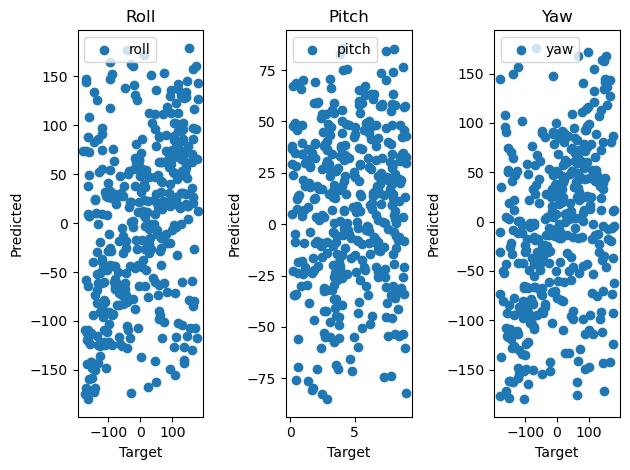

MSE: 6.803332816418431e-05
MAE: 0.006350181274773134


In [61]:
# Plot the predictions and targets
import matplotlib.pyplot as plt

# Create a 3x1 subplot
fig, axes = plt.subplots(1, 3)

# First subplot: roll
axes[0].scatter(val_first_euler_target[:, 0], val_first_euler_pred[:, 0], label="roll")
axes[0].legend()
axes[0].set_title("Roll")
axes[0].set_ylabel("Predicted")
axes[0].set_xlabel("Target")

# Second subplot: pitch
axes[1].scatter(val_first_euler_target[:, 1], val_first_euler_pred[:, 1], label="pitch")
axes[1].legend()
axes[1].set_title("Pitch")
axes[1].set_ylabel("Predicted")
axes[1].set_xlabel("Target")

# Third subplot: yaw
axes[2].scatter(val_first_euler_target[:, 2], val_first_euler_pred[:, 2], label="yaw")
axes[2].legend()
axes[2].set_title("Yaw")
axes[2].set_ylabel("Predicted")
axes[2].set_xlabel("Target")

# Adjust layout
plt.tight_layout()
plt.show()


# Calculate the mean squared error
mse = np.mean((first_vec_pred - first_vec_target) ** 2)
print(f"MSE: {mse}")

# Calculate the mean absolute error
mae = np.mean(np.abs(first_vec_pred - first_vec_target))
print(f"MAE: {mae}")